# Portfolio 2 — NHANES Dietary Predictors of Glycaemic Status
## Notebook 02: Exploratory Analysis

**Goal:** Understand the dataset before modelling — distributions, group differences,
and correlations between dietary/body variables and glucose outcomes.

**Key question this notebook answers:**
Do dietary variables already show a visible signal in the raw data, or does the signal
only emerge after adjusting for body composition?


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Step 1: Load clean dataset and summary statistics

In [2]:
df = pd.read_csv('/Users/larascofano/Documents/Obsidian Vault/career/Portfolio 2/data/nhanes_clean.csv')
print(f"Shape: {df.shape}")
print()
df.describe().round(2)

Shape: (2517, 18)



,SEQN,age,sex,race,income,survey_weight,is_pregnant,fasting glucose (mg/DL),carb_avg,sugar_avg,fiber_avg,fat_avg,kcal_avg,HbA1c (%),vigorous activity,moderate activity,BMI,waist circumference
count,2517.00,2517.00,2517.00,2517.00,2178.00,2517.00,460.00,2517.00,2293.00,2293.00,2293.00,2293.00,2293.00,2514.00,2517.00,2517.00,2472.00,2387.00
mean,98339.90,50.26,1.51,3.49,2.52,45076.78,2.02,113.91,238.72,101.06,16.62,81.52,2025.64,5.86,1.76,1.60,29.64,99.97
std,2694.98,18.45,0.50,1.67,1.59,52410.52,0.15,37.41,110.44,66.23,9.82,40.60,865.78,1.11,0.43,0.49,7.42,17.14
min,93708.00,18.00,1.00,1.00,0.00,4579.58,2.00,47.00,1.00,0.98,0.00,0.48,14.00,3.80,1.00,1.00,15.50,63.20
25%,96033.00,34.00,1.00,3.00,1.20,15843.57,2.00,96.00,166.66,56.50,9.90,53.11,1431.00,5.30,2.00,1.00,24.50,87.35
50%,98320.00,52.00,2.00,3.00,2.07,26337.66,2.00,104.00,224.23,87.88,14.55,75.08,1910.50,5.60,2.00,2.00,28.30,98.60
75%,100680.00,65.00,2.00,4.00,4.06,49610.52,2.00,115.00,294.84,127.90,20.85,102.71,2506.00,6.00,2.00,2.00,33.50,111.00
max,102956.00,80.00,2.00,7.00,5.00,419762.84,3.00,451.00,1063.07,892.64,81.90,347.58,8356.50,15.20,2.00,2.00,86.20,169.50


In [3]:
# Missing values
missing_pct = (df.isnull().sum() / len(df) * 100).round(1)
print("Missing values (%):")
print(missing_pct[missing_pct > 0].to_string())

Missing values (%):
income                 13.5
is_pregnant            81.7
carb_avg                8.9
sugar_avg               8.9
fiber_avg               8.9
fat_avg                 8.9
kcal_avg                8.9
HbA1c (%)               0.1
BMI                     1.8
waist circumference     5.2


## Step 2: Classify glycaemic status

Standard clinical thresholds (ADA guidelines):
- **Normal:** HbA1c < 5.7%
- **Prediabetic:** 5.7% ≤ HbA1c < 6.5%
- **Diabetic:** HbA1c ≥ 6.5%


In [4]:
bins   = [0, 5.7, 6.5, 100]
labels = ['normal', 'prediabetic', 'diabetic']
df['diabetic_status'] = pd.cut(df['HbA1c (%)'], bins=bins, labels=labels, right=False)

counts     = df['diabetic_status'].value_counts()
total      = len(df)
percentage = ((counts / total) * 100).round(1)

print("Glycaemic status classification:")
for status in ['normal', 'prediabetic', 'diabetic']:
    print(f"  {status:<12} n={counts[status]:>5}   ({percentage[status]:.1f}%)")

# Save diabetic_status back to CSV for use in script 03
df.to_csv('/Users/larascofano/Documents/Obsidian Vault/career/Portfolio 2/data/nhanes_clean.csv', index=False)

Glycaemic status classification:
  normal       n= 1386   (55.1%)
  prediabetic  n=  755   (30.0%)
  diabetic     n=  373   (14.8%)


## Step 3: Distribution plots — key continuous variables

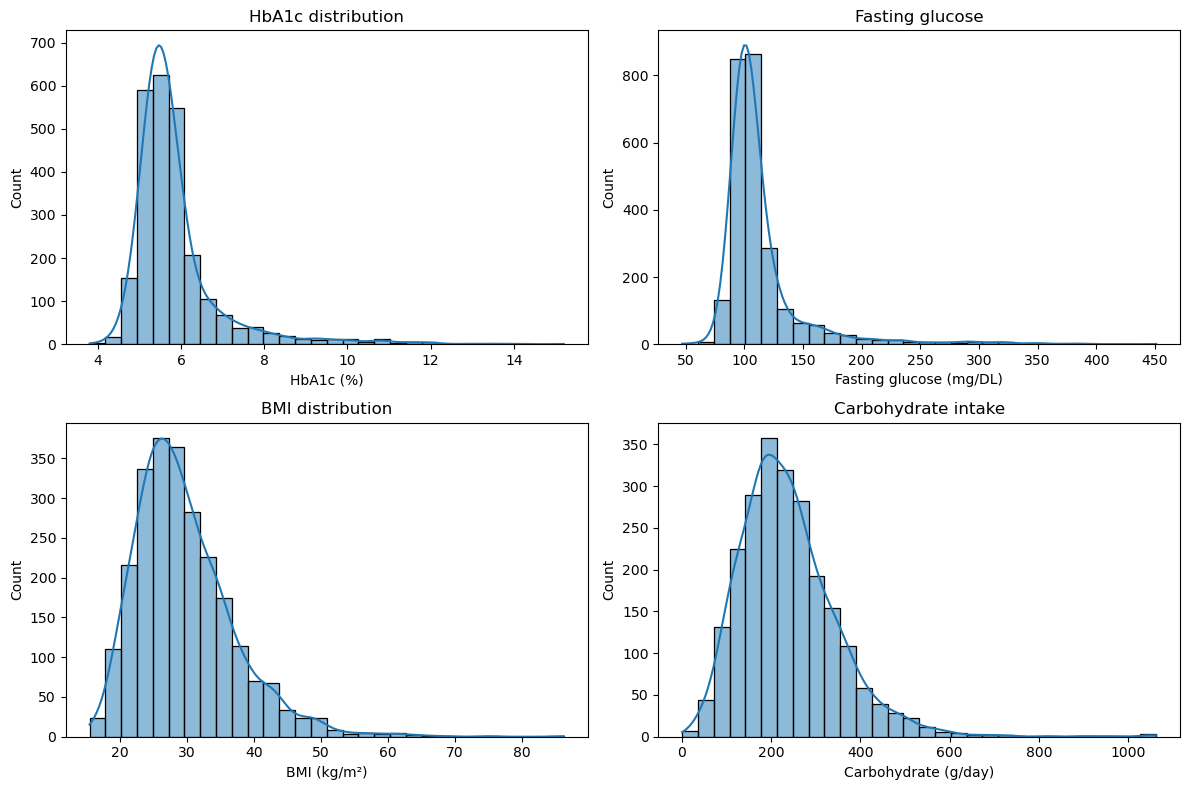

Saved: 02_histogram.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(data=df, x='HbA1c (%)',               bins=30, kde=True, ax=axes[0,0]).set(title='HbA1c distribution',      xlabel='HbA1c (%)',               ylabel='Count')
sns.histplot(data=df, x='fasting glucose (mg/DL)',  bins=30, kde=True, ax=axes[0,1]).set(title='Fasting glucose',         xlabel='Fasting glucose (mg/DL)', ylabel='Count')
sns.histplot(data=df, x='BMI',                      bins=30, kde=True, ax=axes[1,0]).set(title='BMI distribution',        xlabel='BMI (kg/m²)',             ylabel='Count')
sns.histplot(data=df, x='carb_avg',                 bins=30, kde=True, ax=axes[1,1]).set(title='Carbohydrate intake',     xlabel='Carbohydrate (g/day)',    ylabel='Count')

plt.tight_layout()
plt.savefig('/Users/larascofano/Documents/Obsidian Vault/career/Portfolio 2/figures/02_histogram.png')
plt.show()
print("Saved: 02_histogram.png")

**What to look for:**
- HbA1c is right-skewed — most participants are normal, long tail of diabetic values
- BMI peaks around 27–30 kg/m² (overweight range is modal in this US sample)
- Carbohydrate intake shows high variability — heterogeneous dietary patterns

## Step 4: Glycaemic status count plot

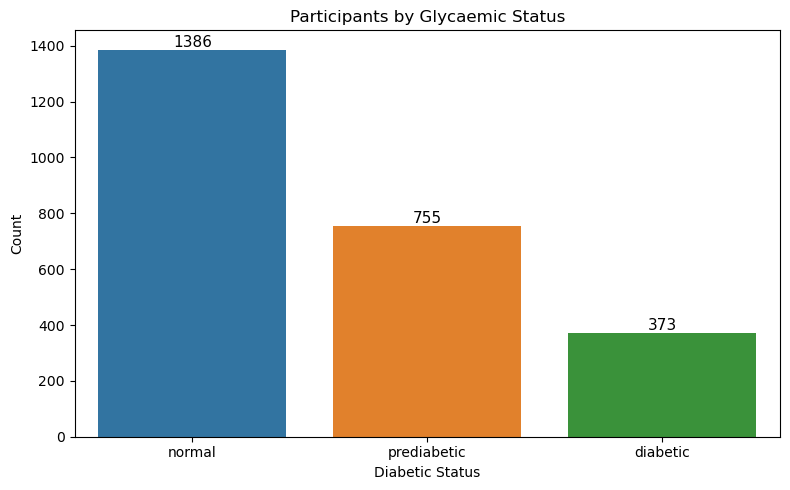

Saved: 02_barplot.png


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=counts.index, y=counts.values, ax=ax)

for i, v in enumerate(counts.values):
    ax.text(i, v + 10, str(v), ha='center', fontsize=11)

ax.set_title('Participants by Glycaemic Status')
ax.set_xlabel('Diabetic Status')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('/Users/larascofano/Documents/Obsidian Vault/career/Portfolio 2/figures/02_barplot.png')
plt.show()
print("Saved: 02_barplot.png")

## Step 5: Boxplots — dietary intake by glycaemic status

**Question:** Do diabetic/prediabetic participants eat differently from normal participants?

If dietary intake is a meaningful predictor, we expect visible differences in these boxplots.
If the boxes largely overlap, that is already a signal that the relationship is weak.

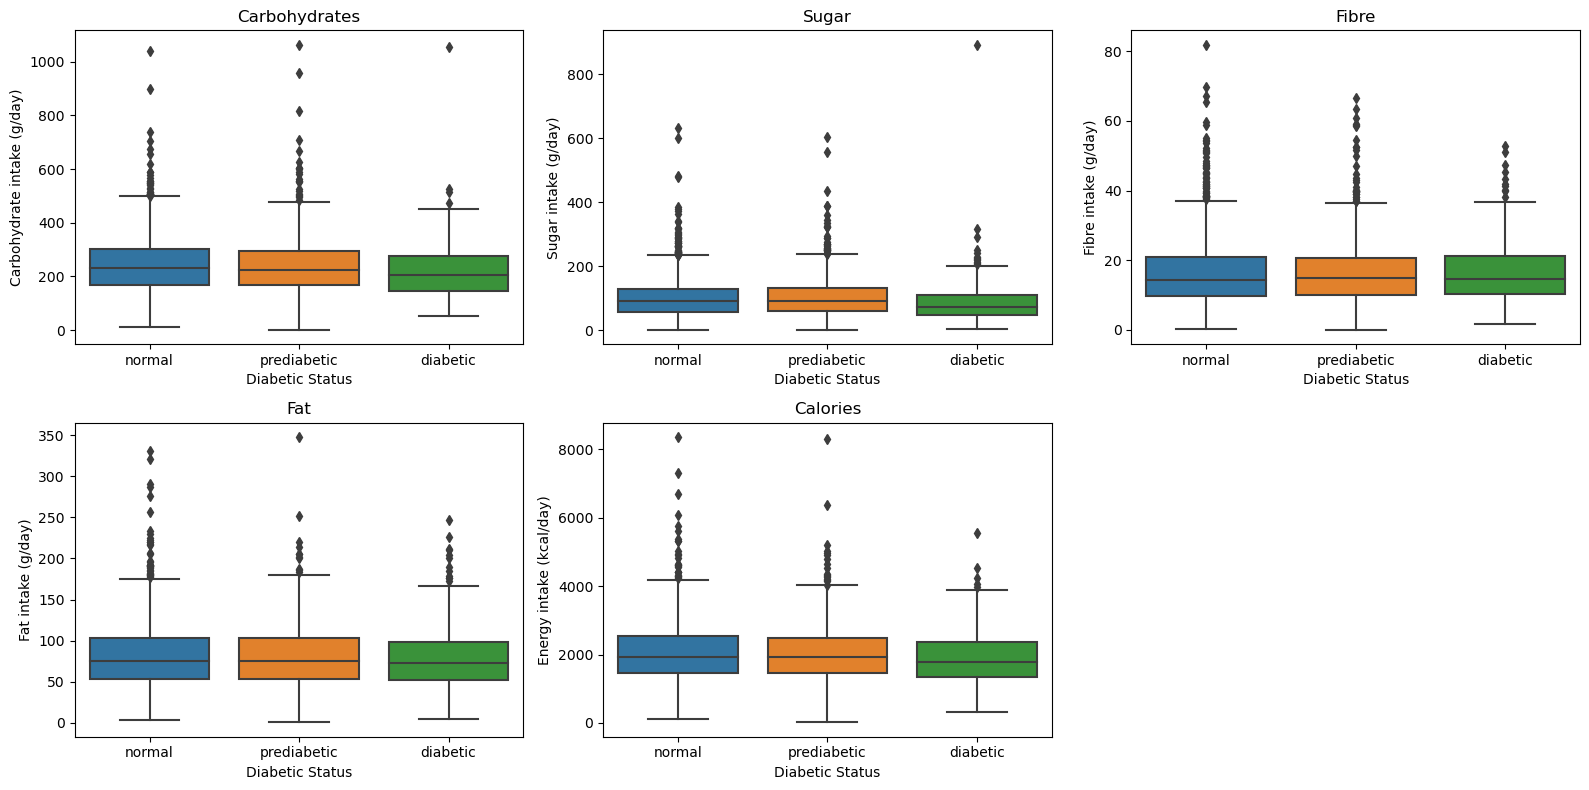

Saved: 02_boxplot.png


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
order = ['normal', 'prediabetic', 'diabetic']

sns.boxplot(data=df, x='diabetic_status', y='carb_avg',  order=order, ax=axes[0,0]).set(title='Carbohydrates', xlabel='Diabetic Status', ylabel='Carbohydrate intake (g/day)')
sns.boxplot(data=df, x='diabetic_status', y='sugar_avg', order=order, ax=axes[0,1]).set(title='Sugar',         xlabel='Diabetic Status', ylabel='Sugar intake (g/day)')
sns.boxplot(data=df, x='diabetic_status', y='fiber_avg', order=order, ax=axes[0,2]).set(title='Fibre',         xlabel='Diabetic Status', ylabel='Fibre intake (g/day)')
sns.boxplot(data=df, x='diabetic_status', y='fat_avg',   order=order, ax=axes[1,0]).set(title='Fat',           xlabel='Diabetic Status', ylabel='Fat intake (g/day)')
sns.boxplot(data=df, x='diabetic_status', y='kcal_avg',  order=order, ax=axes[1,1]).set(title='Calories',      xlabel='Diabetic Status', ylabel='Energy intake (kcal/day)')

axes[1,2].set_visible(False)
plt.tight_layout()
plt.savefig('/Users/larascofano/Documents/Obsidian Vault/career/Portfolio 2/figures/02_boxplot.png')
plt.show()
print("Saved: 02_boxplot.png")

## Step 6: Correlation heatmap

Visualise pairwise correlations between all dietary, body composition, and outcome variables.

Key pairs to look for:
- **HbA1c ↔ fasting glucose:** expected strong positive correlation (both measure glycaemic control)
- **BMI ↔ HbA1c:** expected moderate positive correlation
- **Dietary variables ↔ HbA1c:** hypothesis — do these show a meaningful association?


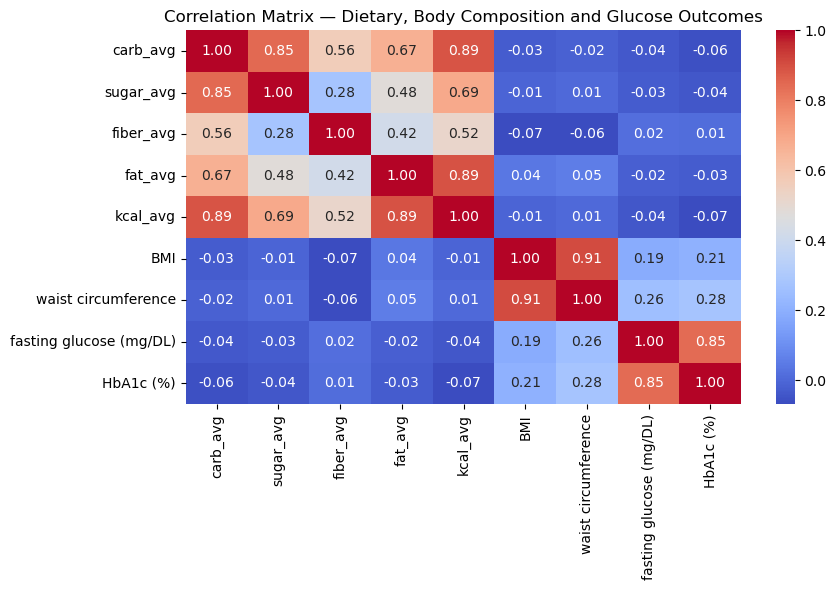

Saved: 02_heatmap.png


In [8]:
cols = ['carb_avg', 'sugar_avg', 'fiber_avg', 'fat_avg', 'kcal_avg',
        'BMI', 'waist circumference', 'fasting glucose (mg/DL)', 'HbA1c (%)']

corr = df[cols].corr()

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', ax=ax)
ax.set_title('Correlation Matrix — Dietary, Body Composition and Glucose Outcomes')
plt.tight_layout()
plt.savefig('/Users/larascofano/Documents/Obsidian Vault/career/Portfolio 2/figures/02_heatmap.png')
plt.show()
print("Saved: 02_heatmap.png")

**Interpretation:**
- HbA1c ↔ fasting glucose: strong positive correlation (expected)
- BMI ↔ HbA1c: moderate positive — adiposity drives chronic glycaemic state
- Dietary variables ↔ HbA1c: weak correlations — consistent with diet being a poor snapshot predictor
- Dietary variables ↔ each other: moderate (kcal drives all macronutrients)

## Step 7: Summary statistics by glycaemic group

In [9]:
summary = df.groupby('diabetic_status')[
    ['age', 'BMI', 'carb_avg', 'sugar_avg', 'fiber_avg', 'fasting glucose (mg/DL)', 'HbA1c (%)']
].mean()

print("Mean values by glycaemic status:")
print(summary.round(2).to_string())

print()
print("Script 02 complete — EDA figures saved to ../figures/")

Mean values by glycaemic status:
                   age    BMI  carb_avg  sugar_avg  fiber_avg  fasting glucose (mg/DL)  HbA1c (%)
diabetic_status                                                                                  
normal           42.98  28.19    242.30     102.68      16.48                    99.92       5.26
prediabetic      57.73  30.82    242.24     104.45      16.82                   109.59       5.93
diabetic         62.33  32.64    217.40      87.78      16.70                   174.80       7.92

Script 02 complete — EDA figures saved to ../figures/
